## Compito Esame

Data la funzione:

$$f(x)=\frac{\sin^2(x + 7/2)e^{(1/5-2x)}}{\log(x+5)}$$


a) Si disegna il grafico di f e si indica quanti zeri ha la funzione nel dominio [-2, 4], Punti:**2**

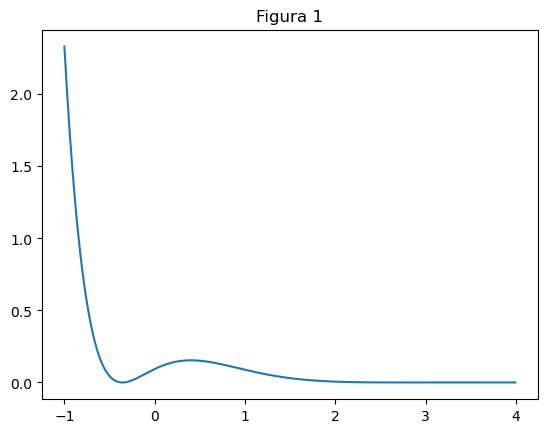

In [1]:
import sympy as sym
import numpy as np
from sympy.utilities.lambdify import lambdify
import matplotlib.pyplot as plt

r = np.arange(-1, 4, 0.01)
f = lambda x: (sym.sin(x + 7/2)**2*sym.exp(1/5-2*x))/sym.log(x+5)
x = sym.Symbol('x')
func = lambdify(x, f(x), np)
plt.plot(r, func(r))
plt.title(r"Figura 1")
plt.show()

b) Si utilizzi il metodo di newton per determinare gli zeri dell'equazione avendo come iterati iniziali $x_0 = -1, x_0 = 4$, assumendo come tolleranza
tolf = 1.e-15 and tolx = 1.e-15, Punti: **5**

In [39]:
from itertools import takewhile
tolf = 1e-15
tolx = 1e-15
nmax = 500

def iterate(func, start):
    while True:
        yield start
        start = func(start)

def newton(f, dx, x0, tolx, tolf, nmax, delta):
    stop_criteria = lambda i, x: i < nmax and abs(dx(x)) >= tolx and abs(delta(f, dx, x)) >= tolx and abs(f(x)) >= tolf

    iter = iterate(lambda xk: xk - delta(f, dx, xk), x0)
    arr = list(dict(takewhile(lambda param: stop_criteria(*param), enumerate(iter))).values()) \
        + [next(iter)]

    return arr[-1], len(arr), arr


In [40]:
m = 1
dx = lambdify(x, sym.diff(f(x), x, m), np)
init_0 = [-1, 4]
sol = [newton(func, dx, x0, tolx, tolf, nmax, lambda f, dx, x: f(x)/dx(x)) for x0 in init_0]
[print(f"Zeri di funzione: {z}") for z, _,_ in sol]

Zeri di funzione: -0.35840735355377573
Zeri di funzione: 5.924772543716909


[None, None]

c) Si diesgni in figura 2 l'andamento degli iterati ottenuti a partire dai valori di innesco x0 = 4 e x0 = -1, Punti:**2**

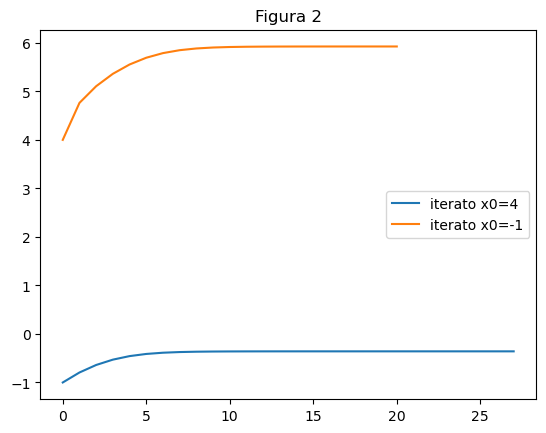

In [36]:
plt.title(r"Figura 2")
[plt.plot(range(i), a) for _, i, a in sol]
plt.legend(['iterato x0=4', 'iterato x0=-1'])
plt.show()

d) Si calcoli, nei due casi implementati in b) una stima dell'ordine di convergenza del metodo; Punti:**3**

In [17]:
def order_evaluation(arr, it):
    order = [
        np.log(abs(arr[k+2] - arr[k+3]) / abs(arr[k+1] - arr[k+2]))/\
        np.log(abs(arr[k+1] - arr[k+2]) / abs(arr[k] - arr[k+1]))\
        for k in range(it-3)
    ]
    return order[-1]

for _, i, a in sol:
    print(f"Stima ordine iterati → {order_evaluation(a, i)}")

Stima ordine iterati → 2.0092112291051243
Stima ordine iterati → 2.020517454161396


e) Qualora l'ordine di convergenza non risulti ottimale, si modifichi opportunatamente il metodo di Newton per renderlo tale (Motivando la modifica implementata); Punti: **4**

In [32]:
import IPython.display as nb
m = 2
sol = [newton(func, dx, x0, tolx, tolf, nmax, lambda f, dx, x: m * f(x)/dx(x)) for x0 in init_0]
for z, _,_ in sol:
    print(f"Zeri di funzione → {z}")
nb.display(nb.Latex(r"Essenzialmente, $f'(\alpha)=0$ dove $\alpha$ è convergente dall'iterato $x_0=-1$, dunque è necesario portare la moltiplecità del delta a 2, (Sicuramente > 1) e la stima dell'ordine risulta approssimamente a 2"))

Zeri di funzione → -0.35840734641020694
Zeri di funzione → 5.9247779607693785


<IPython.core.display.Latex object>

In [19]:
for _, i, a in sol:
    print(f"Stima ordine → {order_evaluation(a, i)}") 

Stima ordine → 2.0092112291051243
Stima ordine → 2.020517454161396


In [7]:
# [plt.plot(range(i), a) for _, i, a in sol]